<a href="https://colab.research.google.com/github/brosangela517-cloud/fatec/blob/main/PROGRAMACAO.Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [3]:
from google.colab import drive

In [4]:
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
origem='/content/drive/My Drive/datas/comexstat/'

In [6]:
arquivo_1=origem+'EXP_2025.csv'
arquivo_2=origem+'EXP_2026.csv'
ncm=origem+'NCM.csv'
pais=origem+'PAIS.csv'
vias=origem+'VIA.csv'
urf=origem+'URF.csv'

In [7]:
exp25=pd.read_csv(arquivo_1,low_memory=False,sep=';',encoding='utf-8')
exp26=pd.read_csv(arquivo_2,low_memory=False,sep=';',encoding='utf-8')
expncm=pd.read_csv(ncm,low_memory=False,sep=';',encoding='latin-1')
exppais=pd.read_csv(pais,low_memory=False,sep=';',encoding='latin-1')
expvias=pd.read_csv(vias,low_memory=False,sep=';',encoding='utf-8')
expurf=pd.read_csv(urf,low_memory=False,sep=';',encoding='latin-1')

In [8]:
exp_final=pd.concat([exp25,exp26],ignore_index=True)

In [9]:
exp_final.head(5)

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB
0,2025,8,71039900,19,687,RS,4,817700,61690,13,203
1,2025,12,2071412,10,741,SC,1,817800,83835,83835,111324
2,2025,11,33059000,10,767,SP,4,817600,792,753,22012
3,2025,11,56031330,10,845,SP,7,1017701,2437,2437,8458
4,2025,6,21069090,10,365,SP,1,817800,4800,4800,17304


In [10]:
exp_final = exp_final.merge(exppais[['CO_PAIS','NO_PAIS']],on='CO_PAIS',how='left')
exp_final = exp_final.merge(expncm[['CO_NCM','NO_NCM_POR']],on='CO_NCM',how='left')

In [11]:
exp_final.head(5)

,CO_ANO,CO_MES,CO_NCM,CO_UNID,CO_PAIS,SG_UF_NCM,CO_VIA,CO_URF,QT_ESTAT,KG_LIQUIDO,VL_FOB,NO_PAIS,NO_NCM_POR
0,2025,8,71039900,19,687,RS,4,817700,61690,13,203,El Salvador,Outras pedras preciosas (exceto diamantes) ou ...
1,2025,12,2071412,10,741,SC,1,817800,83835,83835,111324,Singapura,Coxas com sobrecoxas não desossadas de galinha...
2,2025,11,33059000,10,767,SP,4,817600,792,753,22012,Suíça,Outras preparações capilares
3,2025,11,56031330,10,845,SP,7,1017701,2437,2437,8458,Uruguai,"Falsos tecidos de poliéster, de peso superior ..."
4,2025,6,21069090,10,365,SP,1,817800,4800,4800,17304,Indonésia,Outras preparações alimentícias


In [12]:
coluna = "NO_PAIS"
cp = exp_final[coluna].value_counts().sort_values(ascending=False)
print (f'total de operações{coluna}:')
print(cp)

total de operaçõesNO_PAIS:
NO_PAIS
Paraguai                     172240
Argentina                    168833
Estados Unidos               151029
Uruguai                      114930
Panamá                       113902
                              ...  
Christmas (Navidad), Ilha         2
Eritreia                          1
Santa Helena                      1
Coreia do Norte                   1
Saara Ocidental                   1
Name: count, Length: 247, dtype: int64


In [13]:
exp_final.to_csv(origem+'exp_final.csv',index=False)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


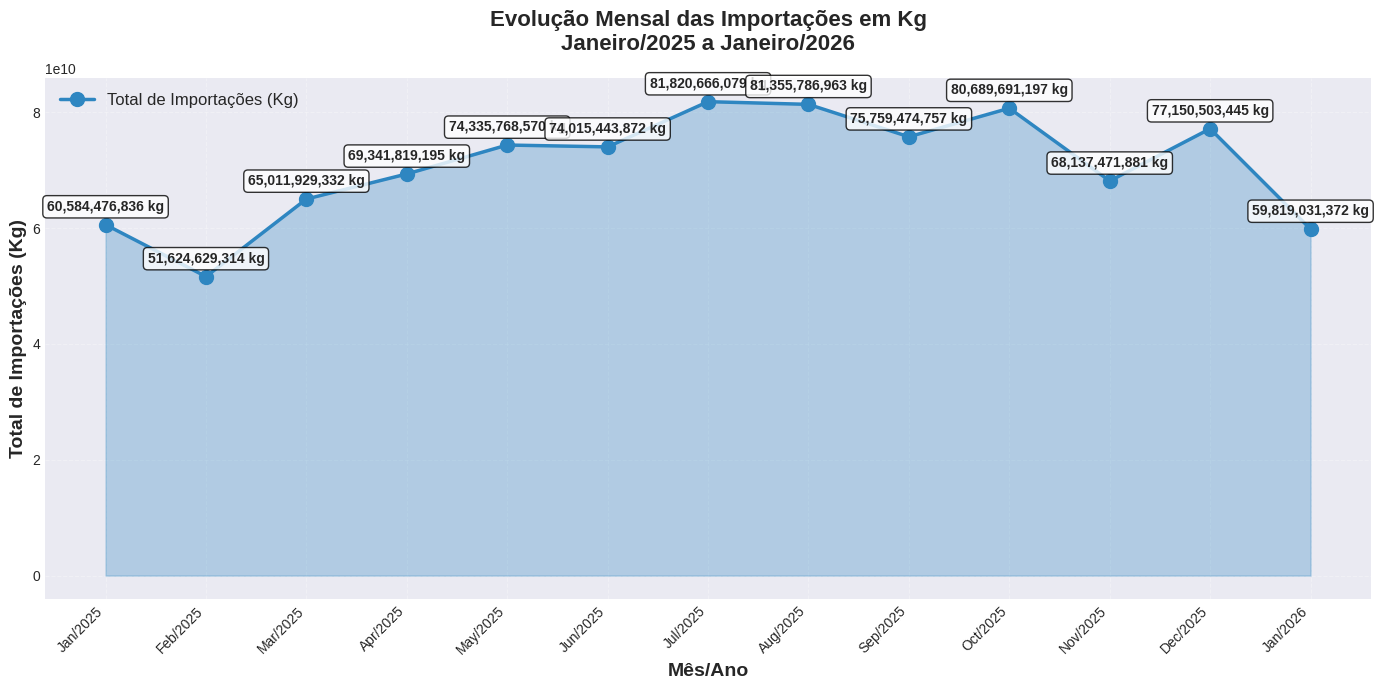

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import calendar

# Montar o drive
drive.mount("/content/drive")

# Carregar os dados
origem = '/content/drive/My Drive/datas/comexstat/'
exp_final = pd.read_csv(origem + 'exp_final.csv', low_memory=False)

# Filtrar dados de janeiro de 2025 a janeiro de 2026
exp_filtrado = exp_final[
    ((exp_final['CO_ANO'] == 2025) & (exp_final['CO_MES'] >= 1)) |
    ((exp_final['CO_ANO'] == 2026) & (exp_final['CO_MES'] == 1))
]

# Agrupar por ano e mês, somando o KG_LIQUIDO
kg_por_mes = exp_filtrado.groupby(['CO_ANO', 'CO_MES'])['KG_LIQUIDO'].sum().reset_index()

# Criar coluna com nome do mês e ano para o eixo X
def nome_mes_ano(ano, mes):
    return f"{calendar.month_abbr[mes]}/{ano}"

kg_por_mes['MES_ANO'] = kg_por_mes.apply(lambda row: nome_mes_ano(row['CO_ANO'], row['CO_MES']), axis=1)

# Ordenar por data
kg_por_mes = kg_por_mes.sort_values(['CO_ANO', 'CO_MES'])

# Converter KG para toneladas para melhor visualização (opcional)
kg_por_mes['TONELADAS'] = kg_por_mes['KG_LIQUIDO'] / 1000

# Configurar o estilo do gráfico
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# CRIAR GRÁFICO DE LINHA
fig, ax = plt.subplots(figsize=(14, 7))

# Plotar a linha
line = ax.plot(kg_por_mes['MES_ANO'], kg_por_mes['KG_LIQUIDO'],
               marker='o', linewidth=2.5, markersize=10,
               color='#2E86C1', label='Total de Importações (Kg)')

# Adicionar área preenchida abaixo da linha
ax.fill_between(kg_por_mes['MES_ANO'], kg_por_mes['KG_LIQUIDO'],
                alpha=0.3, color='#2E86C1')

# Adicionar valores em cima dos pontos
for i, row in kg_por_mes.iterrows():
    ax.annotate(f'{row["KG_LIQUIDO"]:,.0f} kg',
                xy=(row['MES_ANO'], row['KG_LIQUIDO']),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=10, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Configurar eixos e título
ax.set_xlabel('Mês/Ano', fontsize=14, fontweight='bold')
ax.set_ylabel('Total de Importações (Kg)', fontsize=14, fontweight='bold')
ax.set_title('Evolução Mensal das Importações em Kg\nJaneiro/2025 a Janeiro/2026',
             fontsize=16, fontweight='bold', pad=20)

# Rotacionar os labels do eixo X
plt.xticks(rotation=45, ha='right')

# Adicionar grid
ax.grid(True, alpha=0.3, linestyle='--')

# Adicionar legenda
ax.legend(loc='upper left', fontsize=12)

# Ajustar layout
plt.tight_layout()
plt.show()


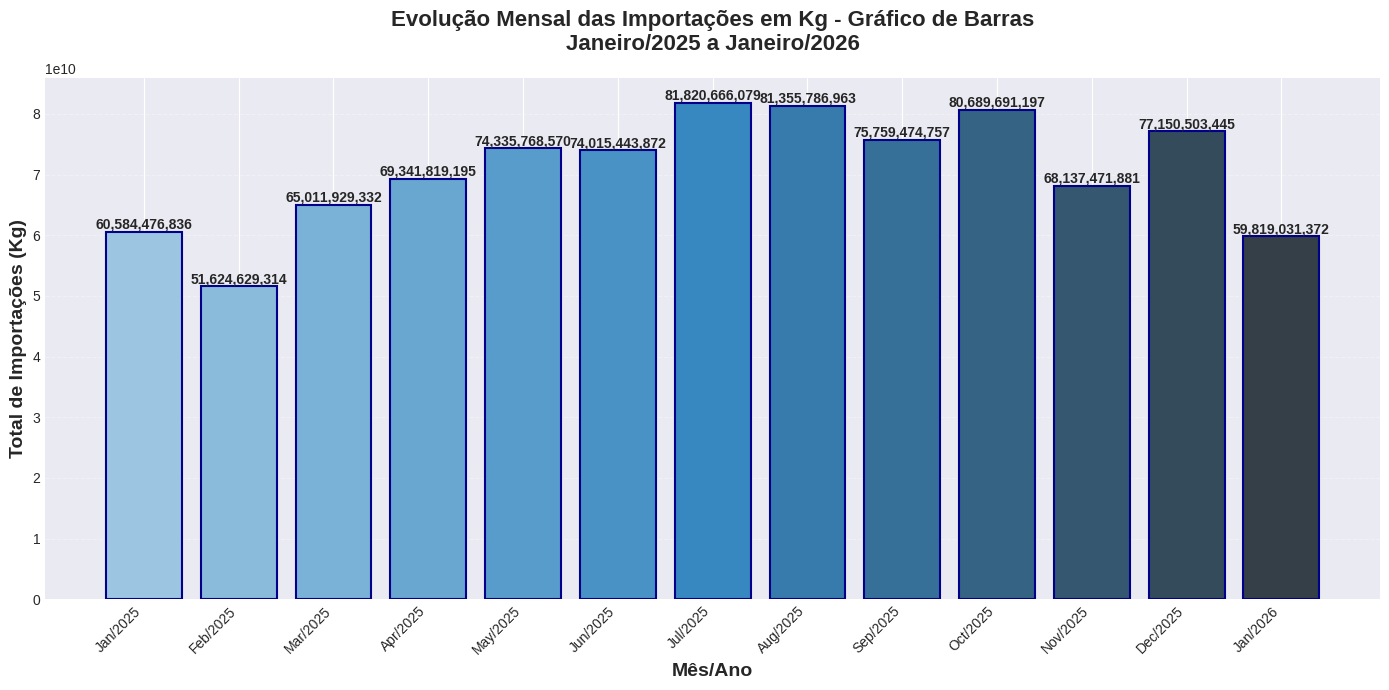

In [17]:
fig, ax = plt.subplots(figsize=(14, 7))

# Criar barras com gradiente de cores
colors = sns.color_palette("Blues_d", len(kg_por_mes))
bars = ax.bar(kg_por_mes['MES_ANO'], kg_por_mes['KG_LIQUIDO'],
              color=colors, edgecolor='darkblue', linewidth=1.5)

# Adicionar valores no topo das barras
for bar, value in zip(bars, kg_por_mes['KG_LIQUIDO']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{value:,.0f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Mês/Ano', fontsize=14, fontweight='bold')
ax.set_ylabel('Total de Importações (Kg)', fontsize=14, fontweight='bold')
ax.set_title('Evolução Mensal das Importações em Kg - Gráfico de Barras\nJaneiro/2025 a Janeiro/2026',
             fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
plt.tight_layout()
plt.show()